# FactoryIO
### modbus_ex2(done) 대상

In [ ]:
# !pip install pymodbus

In [7]:
# 모드버스접속
import pymodbus
from pymodbus.client import ModbusTcpClient
client = ModbusTcpClient('210.119.14.74', port=502)
client.connect()

True

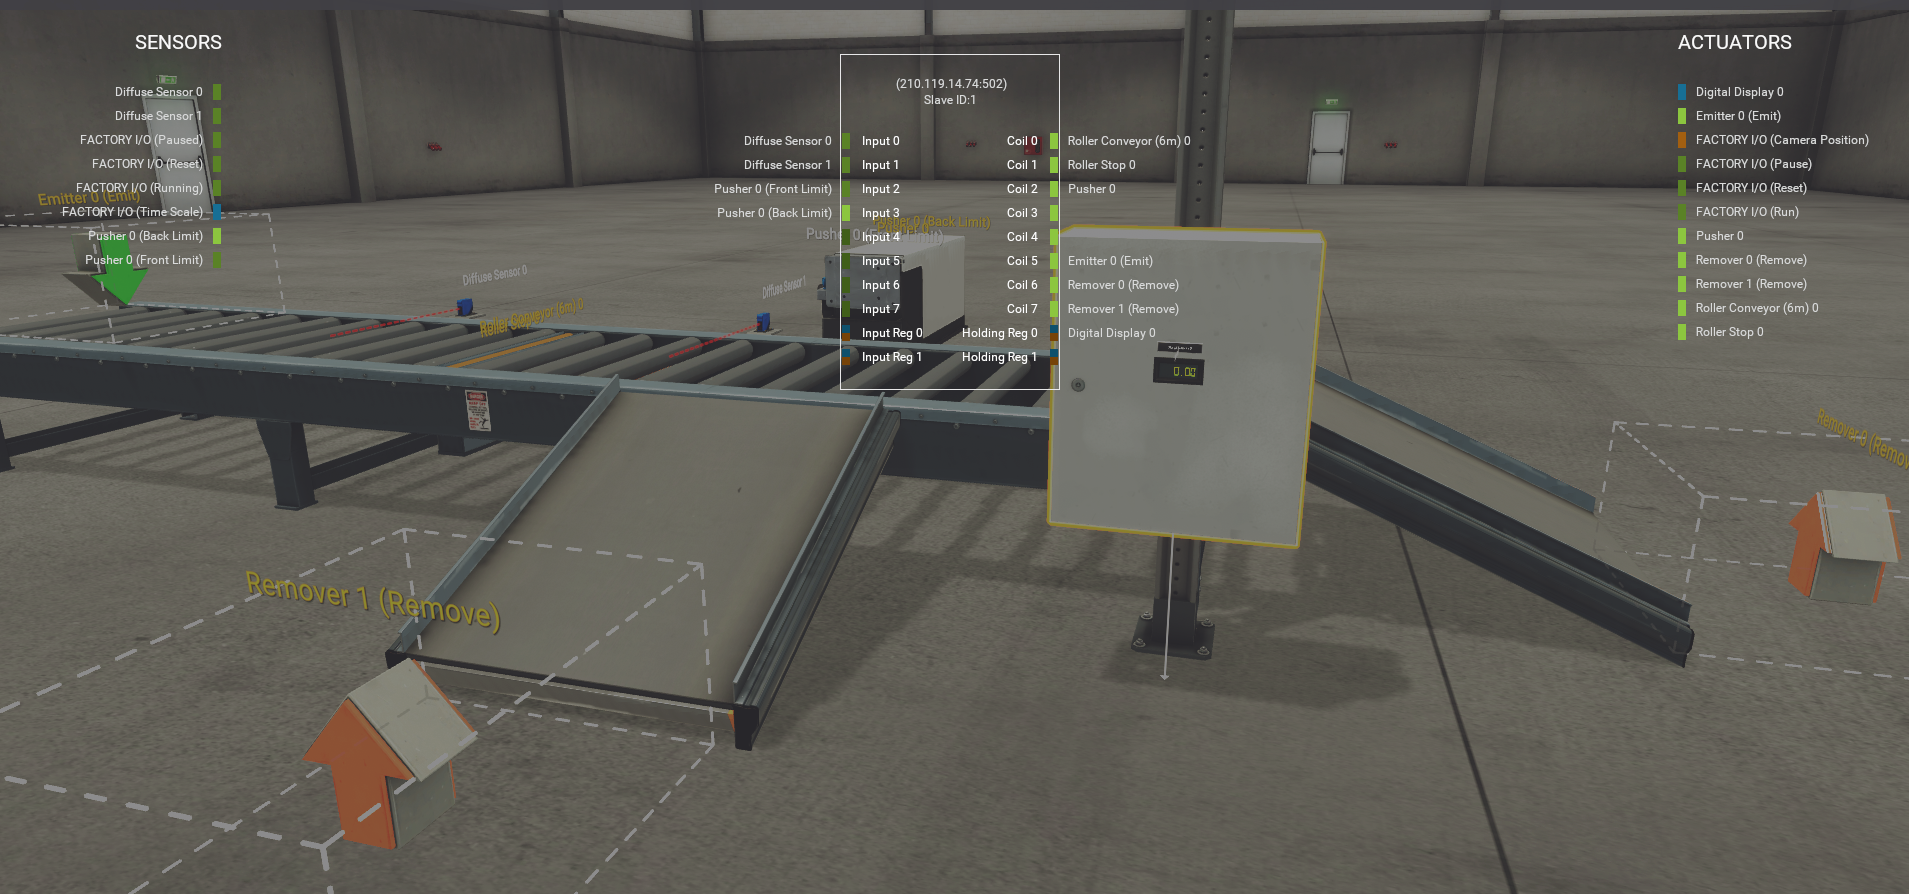

- Diffuse 센서 - 빛을 물체에 쏘아 반사된 빛을 감지해 물체의 존재를 판별하는 광센서 (NO 방식)

In [8]:
# 컨베어, 이미터, 리무버 초기화
client.write_coils(0, [0] * 8)

# client.write_coils(0, 0) #컨베이어
# client.write_coils(1, 0) #스토퍼
# client.write_coils(2, 0) #푸셔
# client.write_coils(5, 0) #생성
# client.write_coils(6, 0) #삭제1
# client.write_coils(7, 0) #삭제2

In [9]:
import time as tt
import threading
# 컨베어, 이미터, 리무버  켜기
client.write_coil(0, 1)
client.write_coil(5, 1)
client.write_coil(6, 1)
client.write_coil(7, 1)
count = [0] #팁 -> 전역 설정 

In [10]:
running = True

def stopper():
    while running:
        sensor = client.read_discrete_inputs(0, count=8, device_id=1).bits[0] # 옛 slave, unit_id
        if sensor:
            client.write_coil(1, 1) # 스토퍼 ON
            tt.sleep(3)
            client.write_coil(1, 0)
            tt.sleep(3)
        else:
            client.write_coil(1, 0) # 스토퍼 OFF
        tt.sleep(0.1)
    print("스캔 종료")
th_stopper = threading.Thread(target= stopper, daemon=True)
print("스레드 시작")
th_stopper.start()

스레드 시작


In [8]:
# 정지
running = False

# 다시 시작
# th_stopper = threading.Thread(target=stopper, daemon=True)
# print("스레드 시작")
# th_stopper.start()

In [12]:
pusher_run = True

def pusher():
    busy = False # 플래그
    while pusher_run:
        sensor2 = client.read_discrete_inputs(0, count=8, device_id=1).bits[1] # 옛 slave, unit_id
        if sensor2 and not busy:
            busy = True
            tt.sleep(1.5)
            client.write_coil(2, 1) # 푸셔 ON
            count[0] += 1
            client.write_register(0,count[0])
        if client.read_discrete_inputs(0, count=8, device_id=1).bits[2]: 
            client.write_coil(2, 0)  # 푸셔 OFF    
            busy = False
        tt.sleep(0.1)
    print("푸셔 스캔 종료")
th_pusher = threading.Thread(target=pusher, daemon=True)
print("푸셔 스레드 시작")
th_pusher.start()

푸셔 스레드 시작


In [28]:
# 정지
pusher_run = False

푸셔스캔종료.
푸셔스캔종료.
